In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
from xgboost import XGBClassifier

In [4]:
from catboost import CatBoostClassifier

In [5]:
!pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [6]:
df = pd.read_csv("Churn_Modelling.csv")

In [7]:
df = df.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

print(df.shape)
print(df.head())

(10000, 11)
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [8]:
TARGET = "Exited"

In [9]:
def create_features(df):
    
    df = df.copy()

    # -----------------------------
    # 1. Balance-related features
    # -----------------------------
    
    df["ZeroBalance"] = (
        df["Balance"] == 0
    ).astype(int)

    df["BalanceSalaryRatio"] = (
        df["Balance"] /
        (df["EstimatedSalary"] + 1)
    )

    # -----------------------------
    # 2. Product-related features
    # -----------------------------

    df["BalancePerProduct"] = (
        df["Balance"] /
        (df["NumOfProducts"] + 1)
    )

    df["SalaryPerProduct"] = (
        df["EstimatedSalary"] /
        (df["NumOfProducts"] + 1)
    )

    # -----------------------------
    # 3. Age / credit features
    # -----------------------------

    df["CreditAgeInteraction"] = (
        df["CreditScore"] * df["Age"]
    )

    # -----------------------------
    # 4. Activity-related features
    # -----------------------------

    df["ActiveTenure"] = (
        df["IsActiveMember"] *
        df["Tenure"]
    )

    df["ActiveAge"] = (
        df["IsActiveMember"] *
        df["Age"]
    )

    df["ProductsActive"] = (
        df["NumOfProducts"] *
        df["IsActiveMember"]
    )

    # -----------------------------
    # 5. Tenure / age relationship
    # -----------------------------

    df["TenureAgeRatio"] = (
        df["Tenure"] /
        (df["Age"] + 1)
    )

    return df

In [10]:
df = create_features(df)

print("Number of features:", df.shape[1])
print(df.columns.tolist())

Number of features: 20
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'ZeroBalance', 'BalanceSalaryRatio', 'BalancePerProduct', 'SalaryPerProduct', 'CreditAgeInteraction', 'ActiveTenure', 'ActiveAge', 'ProductsActive', 'TenureAgeRatio']


In [11]:
df[
    [
        "Balance",
        "EstimatedSalary",
        "BalanceSalaryRatio",
        "ZeroBalance",
        "BalancePerProduct",
        "CreditAgeInteraction",
        "ActiveTenure"
    ]
].head()

,Balance,EstimatedSalary,BalanceSalaryRatio,ZeroBalance,BalancePerProduct,CreditAgeInteraction,ActiveTenure
0,0.00,101348.88,0.000000,1,0.00,25998,2
1,83807.86,112542.58,0.744670,0,41903.93,24928,1
2,159660.80,113931.57,1.401362,0,39915.20,21084,0
3,0.00,93826.63,0.000000,1,0.00,27261,0
4,125510.82,79084.10,1.587035,0,62755.41,36550,2


In [12]:
print(df.isnull().sum())
print(np.isinf(df.select_dtypes(include=np.number)).sum())

CreditScore             0
Geography               0
Gender                  0
Age                     0
Tenure                  0
Balance                 0
NumOfProducts           0
HasCrCard               0
IsActiveMember          0
EstimatedSalary         0
Exited                  0
ZeroBalance             0
BalanceSalaryRatio      0
BalancePerProduct       0
SalaryPerProduct        0
CreditAgeInteraction    0
ActiveTenure            0
ActiveAge               0
ProductsActive          0
TenureAgeRatio          0
dtype: int64
CreditScore             0
Age                     0
Tenure                  0
Balance                 0
NumOfProducts           0
HasCrCard               0
IsActiveMember          0
EstimatedSalary         0
Exited                  0
ZeroBalance             0
BalanceSalaryRatio      0
BalancePerProduct       0
SalaryPerProduct        0
CreditAgeInteraction    0
ActiveTenure            0
ActiveAge               0
ProductsActive          0
TenureAgeRatio          0

In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [14]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [15]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

In [17]:
categorical_features = [
    "Geography",
    "Gender"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Geography', 'Gender']
Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'ZeroBalance', 'BalanceSalaryRatio', 'BalancePerProduct', 'SalaryPerProduct', 'CreditAgeInteraction', 'ActiveTenure', 'ActiveAge', 'ProductsActive', 'TenureAgeRatio']


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [19]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [20]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(feature_names)

['categorical__Geography_Germany' 'categorical__Geography_Spain'
 'categorical__Gender_Male' 'numerical__CreditScore' 'numerical__Age'
 'numerical__Tenure' 'numerical__Balance' 'numerical__NumOfProducts'
 'numerical__HasCrCard' 'numerical__IsActiveMember'
 'numerical__EstimatedSalary' 'numerical__ZeroBalance'
 'numerical__BalanceSalaryRatio' 'numerical__BalancePerProduct'
 'numerical__SalaryPerProduct' 'numerical__CreditAgeInteraction'
 'numerical__ActiveTenure' 'numerical__ActiveAge'
 'numerical__ProductsActive' 'numerical__TenureAgeRatio']


In [21]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_val_processed = pd.DataFrame(
    X_val_processed,
    columns=feature_names,
    index=X_val.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [22]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [23]:
rf_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

In [24]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function w

In [25]:
best_rf = rf_search.best_estimator_

print("Best RF Parameters:")
print(rf_search.best_params_)

print(
    "Best RF CV ROC-AUC:",
    rf_search.best_score_
)

Best RF Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}
Best RF CV ROC-AUC: 0.8532819463429357


In [26]:
def evaluate_model(model, X_data, y_data, threshold=0.5):

    y_prob = model.predict_proba(X_data)[:, 1]

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    print("=" * 60)
    print(f"Threshold: {threshold:.2f}")
    print("=" * 60)

    print(
        "Accuracy:",
        accuracy_score(y_data, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_data, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_data, y_pred)
    )

    print(
        "F1:",
        f1_score(y_data, y_pred)
    )

    print(
        "ROC-AUC:",
        roc_auc_score(y_data, y_prob)
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_data,
            y_pred
        )
    )

    return y_prob, y_pred

In [27]:
rf_val_prob, rf_val_pred = evaluate_model(
    best_rf,
    X_val_processed,
    y_val
)

Threshold: 0.50
Accuracy: 0.8525
Precision: 0.7710843373493976
Recall: 0.39263803680981596
F1: 0.5203252032520326
ROC-AUC: 0.8582456106557773

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1274
           1       0.77      0.39      0.52       326

    accuracy                           0.85      1600
   macro avg       0.82      0.68      0.72      1600
weighted avg       0.84      0.85      0.83      1600



In [28]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [29]:
xgb_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "scale_pos_weight": [1, 2, 3]
}

In [30]:
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [31]:
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [32]:
best_xgb = xgb_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print(
    "Best XGBoost CV ROC-AUC:",
    xgb_search.best_score_
)

Best XGBoost Parameters:
{'subsample': 0.8, 'scale_pos_weight': 2, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best XGBoost CV ROC-AUC: 0.8643745194182364


In [33]:
xgb_val_prob, xgb_val_pred = evaluate_model(
    best_xgb,
    X_val_processed,
    y_val
)

Threshold: 0.50
Accuracy: 0.8525
Precision: 0.6490066225165563
Recall: 0.6012269938650306
F1: 0.6242038216560509
ROC-AUC: 0.8610049021968389

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1274
           1       0.65      0.60      0.62       326

    accuracy                           0.85      1600
   macro avg       0.77      0.76      0.77      1600
weighted avg       0.85      0.85      0.85      1600



In [34]:
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

In [35]:
for col in categorical_features:

    X_train_cat[col] = X_train_cat[col].astype(str)
    X_val_cat[col] = X_val_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

In [37]:
cat = CatBoostClassifier(
    random_seed=42,
    verbose=False,
    loss_function="Logloss",
    eval_metric="AUC"
)

In [38]:
cat_params = {
    "iterations": [300, 500, 700],
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
    "border_count": [32, 64, 128]
}

In [39]:
cat_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=cat_params,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

cat_search.fit(
    X_train_cat,
    y_train,
    cat_features=categorical_features
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'border_count': [32, 64, ...], 'depth': [4, 5, ...], 'iterations': [300, 500, ...], 'l2_leaf_reg': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selec

In [40]:
best_cat = cat_search.best_estimator_

print("Best CatBoost Parameters:")
print(cat_search.best_params_)

print(
    "Best CatBoost CV ROC-AUC:",
    cat_search.best_score_
)

Best CatBoost Parameters:
{'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 700, 'depth': 5, 'border_count': 64}
Best CatBoost CV ROC-AUC: 0.866482361755858


In [41]:
cat_val_prob, cat_val_pred = evaluate_model(
    best_cat,
    X_val_cat,
    y_val
)

Threshold: 0.50
Accuracy: 0.859375
Precision: 0.7790055248618785
Recall: 0.4325153374233129
F1: 0.5562130177514792
ROC-AUC: 0.8658276429967929

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1274
           1       0.78      0.43      0.56       326

    accuracy                           0.86      1600
   macro avg       0.82      0.70      0.74      1600
weighted avg       0.85      0.86      0.84      1600



In [42]:
results = []

models = {
    "Random Forest": (
        best_rf,
        X_val_processed
    ),
    
    "XGBoost": (
        best_xgb,
        X_val_processed
    ),
    
    "CatBoost": (
        best_cat,
        X_val_cat
    )
}

for name, (model, X_data) in models.items():

    y_prob = model.predict_proba(
        X_data
    )[:, 1]

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,CatBoost,0.859375,0.779006,0.432515,0.556213,0.865828
1,XGBoost,0.852500,0.649007,0.601227,0.624204,0.861005
0,Random Forest,0.852500,0.771084,0.392638,0.520325,0.858246


In [43]:
thresholds = np.arange(
    0.20,
    0.71,
    0.05
)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        xgb_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_pred
        ),
        "Recall": recall_score(
            y_val,
            y_pred
        ),
        "F1": f1_score(
            y_val,
            y_pred
        ),
        "Accuracy": accuracy_score(
            y_val,
            y_pred
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1,Accuracy
0,0.20,0.374036,0.892638,0.527174,0.673750
1,0.25,0.424149,0.840491,0.563786,0.735000
2,0.30,0.479478,0.788344,0.596288,0.782500
3,0.35,0.514349,0.714724,0.598203,0.804375
4,0.40,0.566234,0.668712,0.613221,0.828125
5,0.45,0.622093,0.656442,0.638806,0.848750
6,0.50,0.649007,0.601227,0.624204,0.852500
7,0.55,0.702290,0.564417,0.625850,0.862500
8,0.60,0.728889,0.503067,0.595281,0.860625
9,0.65,0.776042,0.457055,0.575290,0.862500


In [44]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.450000
Precision    0.622093
Recall       0.656442
F1           0.638806
Accuracy     0.848750
Name: 5, dtype: float64


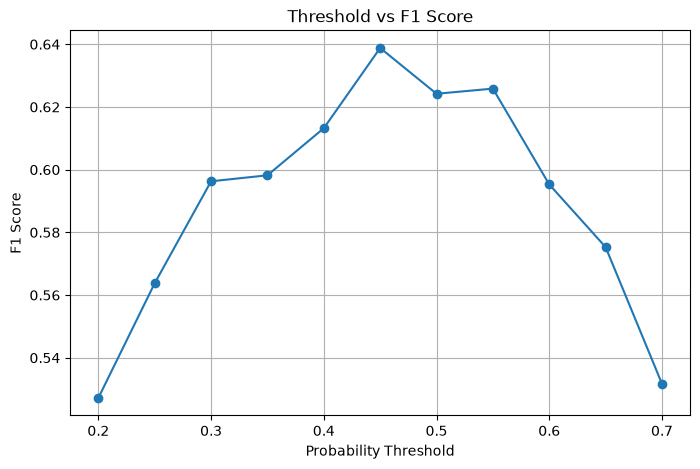

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o"
)

plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")

plt.grid()
plt.show()

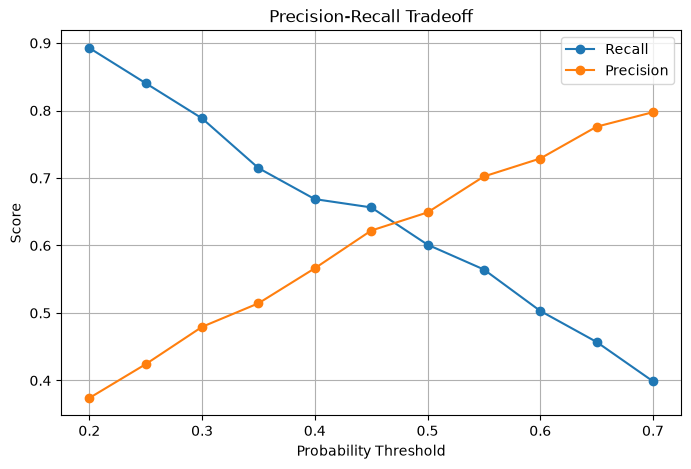

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")

plt.legend()
plt.grid()
plt.show()

In [47]:
best_threshold = float(
    best_threshold_row["Threshold"]
)

In [48]:
xgb_test_prob = best_xgb.predict_proba(
    X_test_processed
)[:, 1]

xgb_test_pred = (
    xgb_test_prob >= best_threshold
).astype(int)

In [49]:
print("FINAL XGBOOST TEST RESULTS")
print("=" * 60)

print(
    "Threshold:",
    best_threshold
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        xgb_test_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        xgb_test_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        xgb_test_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        xgb_test_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_test_prob
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        xgb_test_pred
    )
)

FINAL XGBOOST TEST RESULTS
Threshold: 0.44999999999999996
Accuracy: 0.847
Precision: 0.6150341685649203
Recall: 0.6633906633906634
F1: 0.6382978723404256
ROC-AUC: 0.8666509344475445

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.62      0.66      0.64       407

    accuracy                           0.85      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.85      0.85      2000



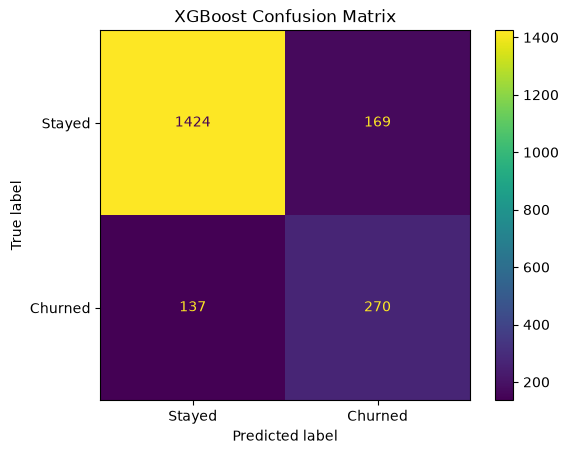

In [50]:
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

In [51]:
pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
import shap

In [53]:
explainer = shap.TreeExplainer(
    best_xgb
)

In [54]:
shap_values = explainer(
    X_test_processed
)

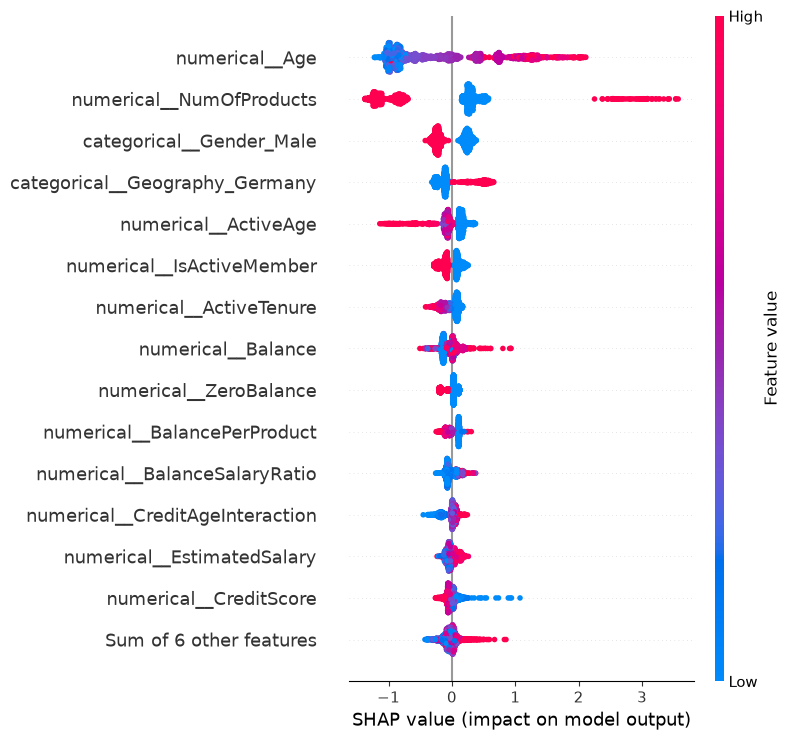

In [55]:
plt.figure()

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

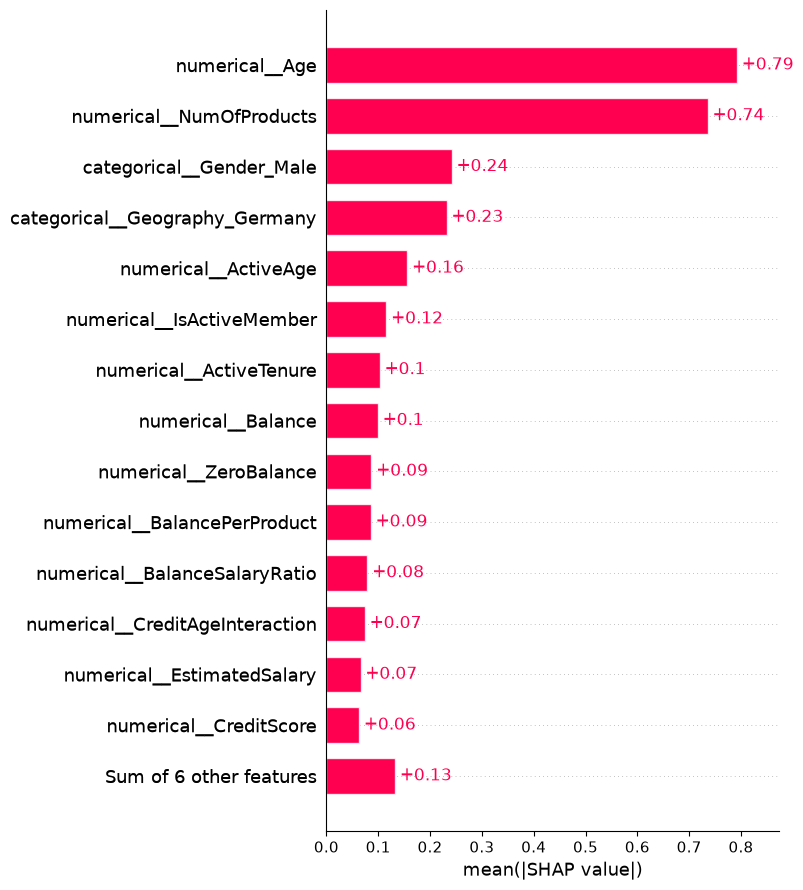

In [56]:
plt.figure()

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

In [57]:
customer_index = 0

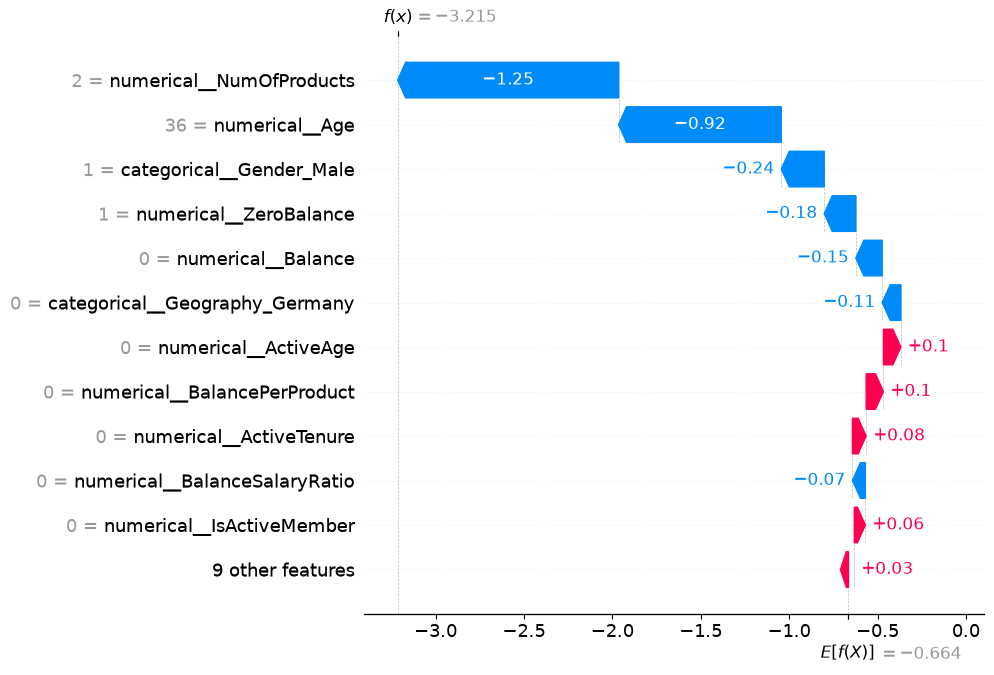

In [58]:
shap.plots.waterfall(
    shap_values[customer_index],
    max_display=12
)

In [59]:
shap_importance = pd.DataFrame({
    "Feature": X_test_processed.columns,
    "MeanAbsSHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
)

shap_importance.head(15)

,Feature,MeanAbsSHAP
4,numerical__Age,0.792136
7,numerical__NumOfProducts,0.735632
2,categorical__Gender_Male,0.241730
0,categorical__Geography_Germany,0.231886
17,numerical__ActiveAge,0.155856
9,numerical__IsActiveMember,0.115535
16,numerical__ActiveTenure,0.102898
6,numerical__Balance,0.099253
11,numerical__ZeroBalance,0.086763
13,numerical__BalancePerProduct,0.085604


In [60]:
shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

In [36]:
import joblib

joblib.dump(
    best_xgb,
    "models/churn_xgboost.pkl"
)

joblib.dump(
    preprocessor,
    "models/preprocessor.pkl"
)

joblib.dump(
    best_threshold,
 
    "models/churn_threshold.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: 'models/churn_xgboost.pkl'